# Descriptive figures

Paper-ready time-series figures for the U.S. macro backdrop and the FDIC-insured banking industry, 1992Q1–2026Q2.

**Inputs**
- `data/processed/1992-2026_RealGDP.csv` — FRED series `GDPC1`, real GDP, billions of chained 2017 dollars, SAAR, quarterly (1990Q1–2026Q2).
- `data/processed/bank_quarter_panel.csv` — bank-quarter panel built by `src/build_panel.py`.

**Outputs** — each figure is written to `output/figures/` as a vector PDF (for LaTeX/Word) and a 300-dpi PNG.

**Conventions**
- Shaded bands are NBER recessions, drawn with FRED's convention: from the first day of the month after the peak through the last day of the trough month.
- Bank data are plotted at the call-report date (quarter end). GDP is a flow over the quarter, so it is plotted at mid-quarter.
- Industry ratios are aggregates, not bank averages: ROA and NIM are weighted by total assets, loan-quality ratios by net loans and leases. FDIC reports ROA, NIM and net charge-offs **year-to-date, annualized**, so Q1 values cover one quarter and Q4 values the full year.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, MaxNLocator

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
FIGS = ROOT / "output" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

## Figure style

One style for every figure: serif text sized for a 6.5-inch text block, fonts embedded as TrueType (most journals require this), recessive axes and grid, and a thin 1.4 pt data line.

In [2]:
INK = "#1a1a1a"        # text and axes
MUTED = "#6b6b6b"      # notes, tick labels
GRID = "#e3e3e3"
SHADE = "#e6e6e6"      # recession bands
SERIES = ["#2a78d6", "#eb6834"]  # blue, orange: validated colorblind-safe pair

WIDTH, HEIGHT = 6.5, 2.9  # inches; full text width

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "text.color": INK,
    "axes.labelcolor": INK,
    "axes.edgecolor": INK,
    "axes.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "xtick.color": INK,
    "ytick.color": INK,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "lines.linewidth": 1.4,
    "legend.frameon": False,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

## Recession shading and shared helpers

NBER business-cycle peaks and troughs (monthly) covering the sample: July 1990–March 1991, March 2001–November 2001, December 2007–June 2009, and February 2020–April 2020.

In [3]:
# (peak month, trough month) from NBER's business cycle chronology
NBER_CYCLES = [
    ("1990-07", "1991-03"),
    ("2001-03", "2001-11"),
    ("2007-12", "2009-06"),
    ("2020-02", "2020-04"),
]
# FRED convention: shade from the month after the peak through the end of the trough month
RECESSIONS = [
    ((pd.Period(peak, "M") + 1).start_time, pd.Period(trough, "M").end_time)
    for peak, trough in NBER_CYCLES
]

X_RANGE = (pd.Timestamp("1992-01-01"), pd.Timestamp("2026-09-30"))


def shade_recessions(ax):
    for start, end in RECESSIONS:
        ax.axvspan(start, end, color=SHADE, lw=0, zorder=0)


def format_time_axis(ax, xlim=X_RANGE):
    ax.set_xlim(*xlim)
    ax.xaxis.set_major_locator(mdates.YearLocator(4, month=1, day=1))
    ax.xaxis.set_minor_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", which="minor", length=2)
    ax.grid(False, axis="x")


def new_figure(height=HEIGHT):
    fig, ax = plt.subplots(figsize=(WIDTH, height))
    shade_recessions(ax)
    return fig, ax


def add_note(fig, text):
    fig.text(0.0, -0.02, text, ha="left", va="top", fontsize=8, color=MUTED, wrap=True, gid="note")


def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(FIGS / f"{name}.{ext}")
    # Caption-ready copy for LaTeX: no in-figure title or note, since the caption carries them
    extras = [t for t in [*fig.texts, fig._suptitle] if t is not None and t.get_gid() in ("note", "title")]
    for t in extras:
        t.set_visible(False)
    fig.savefig(FIGS / f"{name}_bare.pdf")
    for t in extras:
        t.set_visible(True)
    print(f"saved output/figures/{name}.pdf, .png and _bare.pdf")


pct = FuncFormatter(lambda v, _: f"{v:g}%".replace("-", "−"))  # true minus sign

## Real GDP

In [4]:
gdp = pd.read_csv(PROCESSED / "1992-2026_RealGDP.csv", parse_dates=["observation_date"])
gdp = gdp.rename(columns={"observation_date": "date", "GDPC1": "gdp"})
quarter = gdp["date"].dt.to_period("Q")
gdp["date_mid"] = quarter.dt.start_time + (quarter.dt.end_time - quarter.dt.start_time) / 2
gdp["yoy"] = gdp["gdp"].pct_change(4) * 100
gdp.tail()

,date,gdp,date_mid,yoy
141,2025-04-01,23770.976,2025-05-16 11:59:59.999999,2.080467
142,2025-07-01,24026.834,2025-08-15 23:59:59.999999,2.335168
143,2025-10-01,24055.749,2025-11-15 23:59:59.999999,1.989300
144,2026-01-01,24180.419,2026-02-14 23:59:59.999999,2.684743
145,2026-04-01,24269.613,2026-05-16 11:59:59.999999,2.097672


saved output/figures/gdp_level.pdf, .png and _bare.pdf


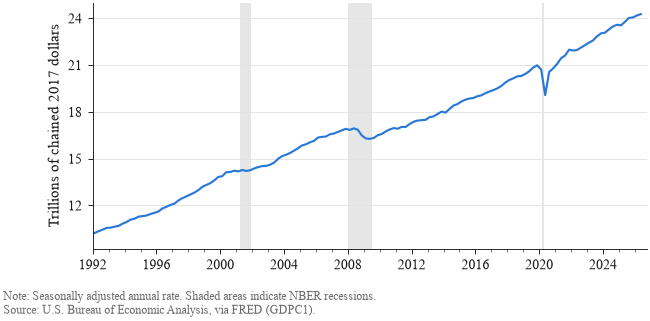

In [5]:
fig, ax = new_figure()
ax.plot(gdp["date_mid"], gdp["gdp"] / 1000, color=SERIES[0])
format_time_axis(ax)
ax.set_ylabel("Trillions of chained 2017 dollars")
ax.yaxis.set_major_locator(MaxNLocator(6))
add_note(fig, "Note: Seasonally adjusted annual rate. Shaded areas indicate NBER recessions.\n"
              "Source: U.S. Bureau of Economic Analysis, via FRED (GDPC1).")
save(fig, "gdp_level")
plt.show()

Year-over-year growth rather than annualized quarter-over-quarter: the 2020Q2–Q3 annualized swings (roughly −28% and +35%) would otherwise set the scale and flatten every other cycle.

saved output/figures/gdp_growth_yoy.pdf, .png and _bare.pdf


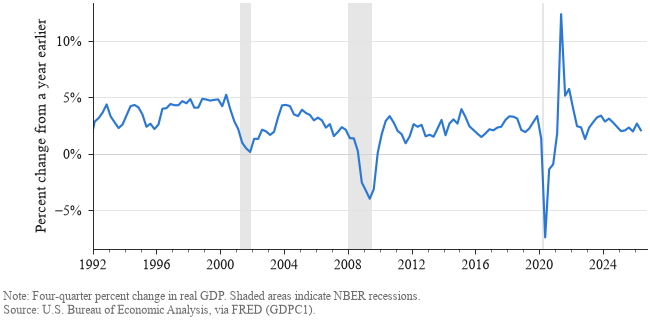

In [6]:
fig, ax = new_figure()
ax.axhline(0, color=INK, lw=0.6, zorder=1)
ax.plot(gdp["date_mid"], gdp["yoy"], color=SERIES[0])
format_time_axis(ax)
ax.set_ylabel("Percent change from a year earlier")
ax.yaxis.set_major_formatter(pct)
add_note(fig, "Note: Four-quarter percent change in real GDP. Shaded areas indicate NBER recessions.\n"
              "Source: U.S. Bureau of Economic Analysis, via FRED (GDPC1).")
save(fig, "gdp_growth_yoy")
plt.show()

## Banking industry aggregates

Only the columns needed here are read from the panel. Dollar amounts in the FDIC files are in thousands.

In [7]:
cols = ["CERT", "REPDTE", "ASSET", "EQ", "LNLSNET", "ROA", "NIMY", "NCLNLSR", "NTLNLSR"]
panel = pd.read_csv(PROCESSED / "bank_quarter_panel.csv", usecols=cols)
panel["date"] = pd.to_datetime(panel["REPDTE"].astype(str), format="%Y%m%d")
panel["loan_w"] = panel["LNLSNET"].clip(lower=0)  # a handful of negative net-loan entries
print(f"{len(panel):,} bank-quarters, {panel['CERT'].nunique():,} banks, "
      f"{panel['date'].min():%Y-%m-%d} to {panel['date'].max():%Y-%m-%d}")

1,129,925 bank-quarters, 17,161 banks, 1992-03-31 to 2026-06-30


In [8]:
def weighted_mean(df, value, weight):
    ok = df[value].notna() & df[weight].notna()
    return np.average(df.loc[ok, value], weights=df.loc[ok, weight])


industry = panel.groupby("date").apply(
    lambda q: pd.Series({
        "n_banks": q["CERT"].nunique(),
        "assets_tn": q["ASSET"].sum() / 1e9,               # thousands -> trillions
        "equity_ratio": q["EQ"].sum() / q["ASSET"].sum() * 100,
        "roa": weighted_mean(q, "ROA", "ASSET"),
        "nim": weighted_mean(q, "NIMY", "ASSET"),
        "noncurrent": weighted_mean(q, "NCLNLSR", "loan_w"),
        "chargeoffs": weighted_mean(q, "NTLNLSR", "loan_w"),
    }),
    include_groups=False,
)
industry.round(2).iloc[[0, 63, 69, 112, 113, -1]]

,n_banks,assets_tn,equity_ratio,roa,nim,noncurrent,chargeoffs
date,,,,,,,
1992-03-31,14423.0,4.58,6.73,0.77,3.97,3.64,1.06
2007-12-31,8544.0,13.05,10.32,0.82,3.30,1.41,0.59
2009-06-30,8204.0,13.31,10.40,-0.23,3.44,4.33,2.18
2020-03-31,5125.0,20.34,10.40,0.39,3.08,0.93,0.52
2020-06-30,5075.0,21.24,10.11,0.37,2.94,1.07,0.52
2026-06-30,4247.0,26.58,9.87,1.31,3.29,0.93,0.56


saved output/figures/banks_count.pdf, .png and _bare.pdf


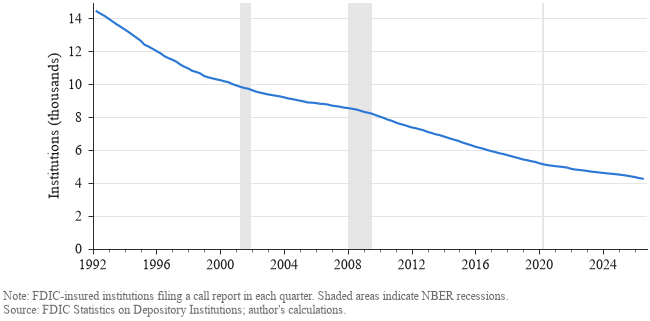

In [9]:
fig, ax = new_figure()
ax.plot(industry.index, industry["n_banks"] / 1000, color=SERIES[0])
format_time_axis(ax)
ax.set_ylabel("Institutions (thousands)")
ax.set_ylim(0, None)
add_note(fig, "Note: FDIC-insured institutions filing a call report in each quarter. Shaded areas indicate NBER recessions.\n"
              "Source: FDIC Statistics on Depository Institutions; author's calculations.")
save(fig, "banks_count")
plt.show()

saved output/figures/banks_total_assets.pdf, .png and _bare.pdf


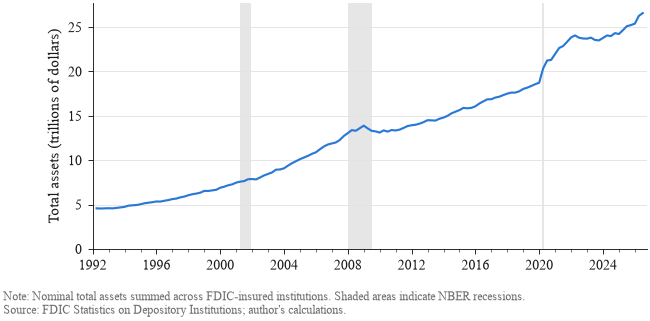

In [10]:
fig, ax = new_figure()
ax.plot(industry.index, industry["assets_tn"], color=SERIES[0])
format_time_axis(ax)
ax.set_ylabel("Total assets (trillions of dollars)")
ax.set_ylim(0, None)
add_note(fig, "Note: Nominal total assets summed across FDIC-insured institutions. Shaded areas indicate NBER recessions.\n"
              "Source: FDIC Statistics on Depository Institutions; author's calculations.")
save(fig, "banks_total_assets")
plt.show()

saved output/figures/banks_roa.pdf, .png and _bare.pdf


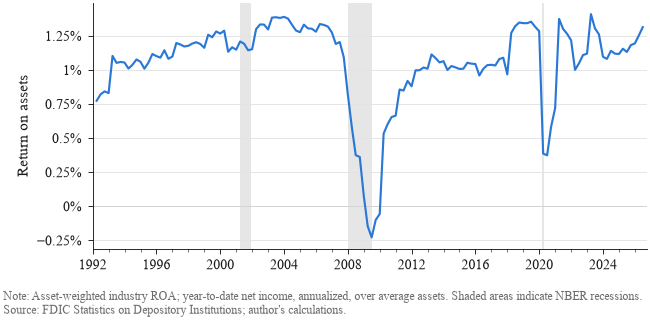

In [11]:
fig, ax = new_figure()
ax.axhline(0, color=INK, lw=0.6, zorder=1)
ax.plot(industry.index, industry["roa"], color=SERIES[0])
format_time_axis(ax)
ax.set_ylabel("Return on assets")
ax.yaxis.set_major_formatter(pct)
add_note(fig, "Note: Asset-weighted industry ROA; year-to-date net income, annualized, over average assets. "
              "Shaded areas indicate NBER recessions.\n"
              "Source: FDIC Statistics on Depository Institutions; author's calculations.")
save(fig, "banks_roa")
plt.show()

saved output/figures/banks_nim.pdf, .png and _bare.pdf


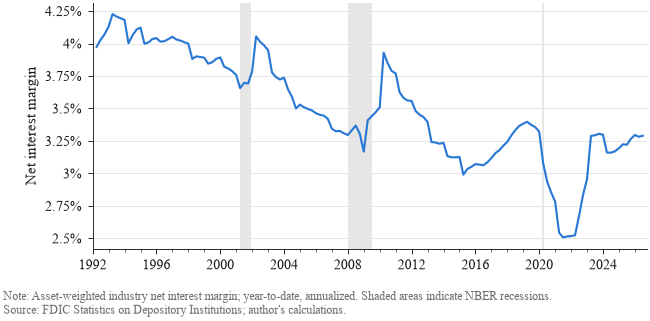

In [12]:
fig, ax = new_figure()
ax.plot(industry.index, industry["nim"], color=SERIES[0])
format_time_axis(ax)
ax.set_ylabel("Net interest margin")
ax.yaxis.set_major_formatter(pct)
add_note(fig, "Note: Asset-weighted industry net interest margin; year-to-date, annualized. "
              "Shaded areas indicate NBER recessions.\n"
              "Source: FDIC Statistics on Depository Institutions; author's calculations.")
save(fig, "banks_nim")
plt.show()

Both loan-quality measures share one unit (percent of loans), so they share one axis.

saved output/figures/banks_loan_quality.pdf, .png and _bare.pdf


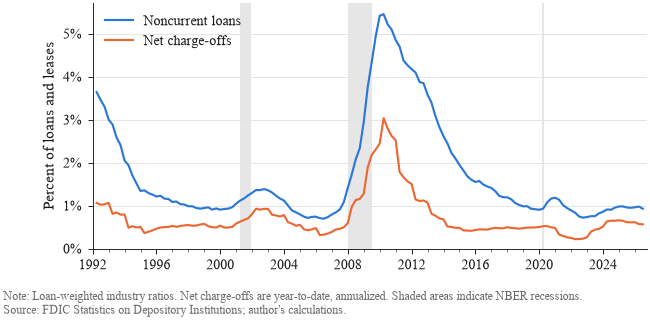

In [13]:
fig, ax = new_figure()
series = [("noncurrent", "Noncurrent loans"), ("chargeoffs", "Net charge-offs")]
for (col, label), color in zip(series, SERIES):
    ax.plot(industry.index, industry[col], color=color, label=label)
format_time_axis(ax)
ax.set_ylabel("Percent of loans and leases")
ax.yaxis.set_major_formatter(pct)
ax.set_ylim(0, None)
ax.legend(loc="upper left")

add_note(fig, "Note: Loan-weighted industry ratios. Net charge-offs are year-to-date, annualized. "
              "Shaded areas indicate NBER recessions.\n"
              "Source: FDIC Statistics on Depository Institutions; author's calculations.")
save(fig, "banks_loan_quality")
plt.show()

saved output/figures/banks_equity_ratio.pdf, .png and _bare.pdf


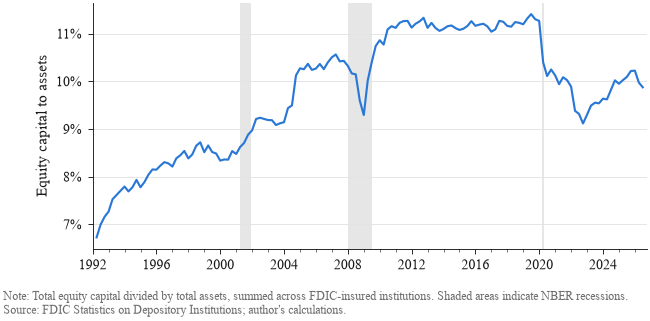

In [14]:
fig, ax = new_figure()
ax.plot(industry.index, industry["equity_ratio"], color=SERIES[0])
format_time_axis(ax)
ax.set_ylabel("Equity capital to assets")
ax.yaxis.set_major_formatter(pct)
add_note(fig, "Note: Total equity capital divided by total assets, summed across FDIC-insured institutions. "
              "Shaded areas indicate NBER recessions.\n"
              "Source: FDIC Statistics on Depository Institutions; author's calculations.")
save(fig, "banks_equity_ratio")
plt.show()

### Aggregate versus typical bank

Asset-weighted aggregates are dominated by the largest institutions. The median bank and the interquartile range show the experience of the typical (small) bank.

saved output/figures/banks_roa_distribution.pdf, .png and _bare.pdf


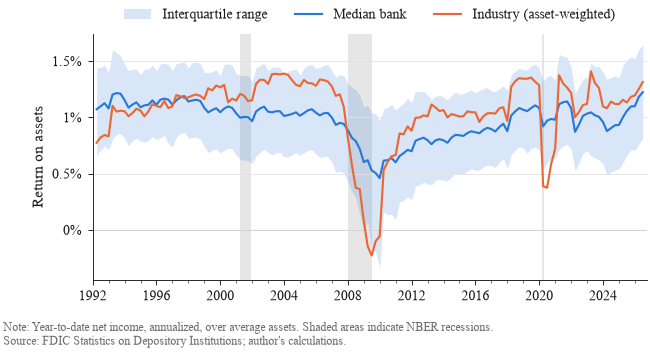

In [15]:
roa_dist = panel.groupby("date")["ROA"].quantile([0.25, 0.5, 0.75]).unstack()

fig, ax = new_figure()
ax.axhline(0, color=INK, lw=0.6, zorder=1)
ax.fill_between(roa_dist.index, roa_dist[0.25], roa_dist[0.75], color=SERIES[0], alpha=0.18,
                lw=0, label="Interquartile range", zorder=1)
ax.plot(roa_dist.index, roa_dist[0.5], color=SERIES[0], label="Median bank")
ax.plot(industry.index, industry["roa"], color=SERIES[1], label="Industry (asset-weighted)")
format_time_axis(ax)
ax.set_ylabel("Return on assets")
ax.yaxis.set_major_formatter(pct)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncols=3)
add_note(fig, "Note: Year-to-date net income, annualized, over average assets. Shaded areas indicate NBER recessions.\n"
              "Source: FDIC Statistics on Depository Institutions; author's calculations.")
save(fig, "banks_roa_distribution")
plt.show()

## Distributions by bank size: quarterly changes

How the largest banks react compared with everyone else. Each quarter, banks are ranked by total assets. The top `TOP_PCT` percent form one group and the rest the other. Membership is re-assigned every quarter, based on size in the current quarter *t*.

The variable of interest is each bank's change from *k* = 1, 2 and 3 quarters earlier, matched to the same bank (CERT):

| Variable | Change measured as |
|---|---|
| Total assets | percent change, $100 \times (A_t / A_{t-k} - 1)$ |
| Equity capital to assets | percentage-point difference |
| Return on assets | percentage-point difference in **single-quarter** ROA |
| Net interest margin | percentage-point difference in **single-quarter** NIM |

Asset changes are in percent because dollar changes are not comparable across banks whose sizes differ by several orders of magnitude.

**Why single-quarter ROA and NIM.** FDIC reports both year-to-date and annualized. Differencing those directly compares a Q1-only figure with a full-year figure every first quarter. So each bank's single-quarter ratio is recovered first, using $r^{q}_{Q} = Q \cdot r^{ytd}_{Q} - (Q-1) \cdot r^{ytd}_{Q-1}$ within a calendar year, with $r^q_1 = r^{ytd}_1$. The formula is exact when average assets are stable within the year, and a close approximation otherwise. Single-quarter ROA keeps its real year-end seasonality: banks book provisions and write-downs in Q4.

In each figure, rows are the lag *k* and columns are the size groups; all six panels share one y-axis. The solid line is the median bank, the dark band the 25th–75th percentiles and the light band the 10th–90th.

In [16]:
TOP_PCT = 1       # size cutoff: top TOP_PCT percent of banks by total assets, re-ranked each quarter
LAGS = (1, 2, 3)  # quarters over which each change is taken

banks = panel.loc[panel["ASSET"] > 0, ["CERT", "date", "ASSET", "EQ", "ROA", "NIMY"]].copy()
banks["quarter"] = banks["date"].dt.quarter
banks["equity_ratio"] = banks["EQ"] / banks["ASSET"] * 100


def shift_quarters(df, cols, k):
    # Same bank's values k quarter-ends earlier, keyed to the current date
    out = df[["CERT", "date", *cols]].copy()
    out["date"] = out["date"] + pd.offsets.QuarterEnd(k)
    return out.rename(columns={c: f"{c}_lag{k}" for c in cols})


# Year-to-date annualized ratios -> single-quarter annualized ratios
banks = banks.merge(shift_quarters(banks, ["ROA", "NIMY"], 1), on=["CERT", "date"], how="left")
q = banks["quarter"]
for ytd, single in [("ROA", "roa"), ("NIMY", "nim")]:
    banks[single] = np.where(q == 1, banks[ytd], q * banks[ytd] - (q - 1) * banks[f"{ytd}_lag1"])
banks = banks.drop(columns=["ROA_lag1", "NIMY_lag1"])

size_rank = banks.groupby("date")["ASSET"].rank(pct=True, ascending=False)
banks["size_group"] = np.where(size_rank <= TOP_PCT / 100, "top", "rest")

n_top = banks[banks["size_group"] == "top"].groupby("date").size()
print(f"Top {TOP_PCT}% group: {n_top.min()}–{n_top.max()} banks per quarter")

Top 1% group: 42–144 banks per quarter


In [17]:
LEVELS = ["ASSET", "equity_ratio", "roa", "nim"]
for k in LAGS:
    banks = banks.merge(shift_quarters(banks, LEVELS, k), on=["CERT", "date"], how="left")
    banks[f"assets_d{k}"] = (banks["ASSET"] / banks[f"ASSET_lag{k}"] - 1) * 100
    for v in ["equity_ratio", "roa", "nim"]:
        banks[f"{v}_d{k}"] = banks[v] - banks[f"{v}_lag{k}"]

DIFF_VARS = {
    "assets": "Change in total assets (%)",
    "equity_ratio": "Change in equity capital to assets (percentage points)",
    "roa": "Change in return on assets (percentage points)",
    "nim": "Change in net interest margin (percentage points)",
}
QUANTILES = [0.10, 0.25, 0.50, 0.75, 0.90]
diff_cols = [f"{v}_d{k}" for v in DIFF_VARS for k in LAGS]

dist = (banks.groupby(["size_group", "date"])[diff_cols]
             .quantile(QUANTILES)
             .unstack())  # columns: (variable_dk, quantile)

# Range of the 10th-90th band across quarters, to judge where axes need capping
bands = pd.DataFrame({c: [dist.loc[:, (c, 0.10)].min(), dist.loc[:, (c, 0.90)].max(),
                          dist.loc[:, (c, 0.10)].quantile(0.02), dist.loc[:, (c, 0.90)].quantile(0.98)]
                      for c in diff_cols}, index=["p10 min", "p90 max", "p10 2%", "p90 98%"]).T
bands.round(2)

,p10 min,p90 max,p10 2%,p90 98%
assets_d1,-10.36,28.56,-6.37,21.46
assets_d2,-12.87,54.81,-7.84,39.31
assets_d3,-14.68,118.00,-9.71,61.76
equity_ratio_d1,-2.34,2.74,-1.53,1.55
equity_ratio_d2,-3.82,4.23,-2.27,2.31
equity_ratio_d3,-4.83,4.77,-2.80,3.14
roa_d1,-6.72,6.78,-2.32,2.11
roa_d2,-7.37,6.57,-2.32,2.12
roa_d3,-7.57,6.09,-2.82,2.43
nim_d1,-1.03,1.04,-0.73,0.65


Merger quarters push the top-1% asset-change tail far beyond everything else, and the 2008–09 losses do the same for top-1% ROA. Where a tail would flatten the rest of a figure, the shared axis is capped (`Y_LIMITS` below), and the figure note says so. The medians and inner bands always stay in view.

In [18]:
Y_LIMITS = {"assets": (-15, 30), "roa": (-3, 3)}

GROUPS = {
    "top": (f"Top {TOP_PCT}% of banks by assets", SERIES[0]),
    "rest": (f"Other {100 - TOP_PCT}% of banks", SERIES[1]),
}
BAND_NOTE = ("Solid line: median bank; dark band: 25th–75th percentiles; light band: 10th–90th percentiles. "
             "Shaded areas indicate NBER recessions.")
SOURCE = "\nSource: FDIC Statistics on Depository Institutions; author's calculations."
signed = FuncFormatter(lambda v, _: f"{v:g}".replace("-", "−"))


def style_box(ax, years_between_ticks=8):
    format_time_axis(ax)
    ax.xaxis.set_major_locator(mdates.YearLocator(years_between_ticks, month=1, day=1))
    for side in ("top", "right"):
        ax.spines[side].set_visible(True)
    ax.grid(True, axis="both", color=GRID, lw=0.6)
    ax.set_axisbelow(True)


def plot_fan(ax, col, group):
    d = dist.loc[group, col]
    color = GROUPS[group][1]
    shade_recessions(ax)
    ax.fill_between(d.index, d[0.10], d[0.90], color=color, alpha=0.16, lw=0, zorder=1)
    ax.fill_between(d.index, d[0.25], d[0.75], color=color, alpha=0.36, lw=0, zorder=2)
    ax.axhline(0, color=INK, lw=0.7, ls=(0, (4, 3)), zorder=3)
    ax.plot(d.index, d[0.50], color=color, lw=1.3, zorder=4)
    style_box(ax)


def lag_figure(var):
    fig, axes = plt.subplots(len(LAGS), 2, figsize=(WIDTH, 7.0), sharex=True, sharey=True)
    for row, k in zip(axes, LAGS):
        for ax, group in zip(row, GROUPS):
            plot_fan(ax, f"{var}_d{k}", group)
        row[0].set_ylabel(f"{k}-quarter change")
    for ax, group in zip(axes[0], GROUPS):
        ax.set_title(GROUPS[group][0], fontsize=9.5)
    axes[0, 0].yaxis.set_major_formatter(pct if var == "assets" else signed)
    if var in Y_LIMITS:
        axes[0, 0].set_ylim(*Y_LIMITS[var])
    fig.suptitle(DIFF_VARS[var], fontsize=11, gid="title")
    fig.align_ylabels(axes[:, 0])
    fig.tight_layout(h_pad=0.8, w_pad=1.2)
    return fig, axes

saved output/figures/size_diff_assets.pdf, .png and _bare.pdf


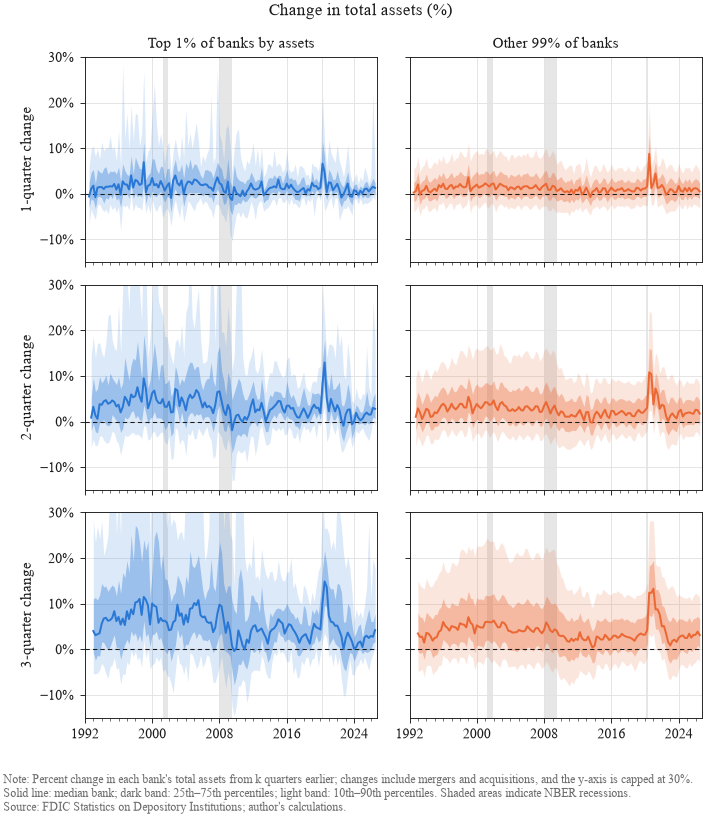

In [19]:
fig, axes = lag_figure("assets")
add_note(fig, "Note: Percent change in each bank's total assets from k quarters earlier; changes include mergers "
              f"and acquisitions, and the y-axis is capped at {Y_LIMITS['assets'][1]}%. " + BAND_NOTE + SOURCE)
save(fig, "size_diff_assets")
plt.show()

saved output/figures/size_diff_equity_ratio.pdf, .png and _bare.pdf


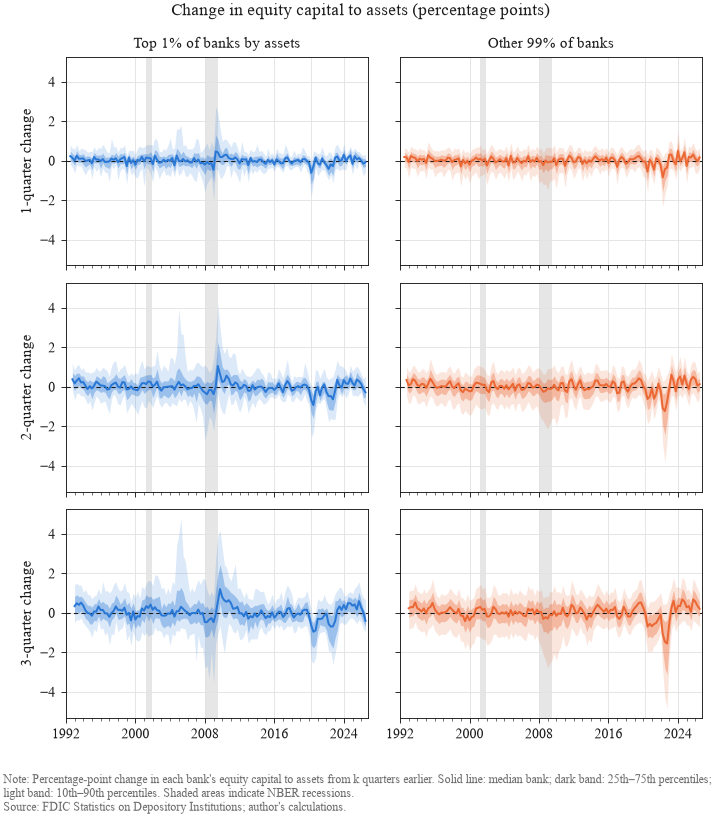

In [20]:
fig, axes = lag_figure("equity_ratio")
add_note(fig, "Note: Percentage-point change in each bank's equity capital to assets from k quarters earlier. "
              + BAND_NOTE + SOURCE)
save(fig, "size_diff_equity_ratio")
plt.show()

saved output/figures/size_diff_roa.pdf, .png and _bare.pdf


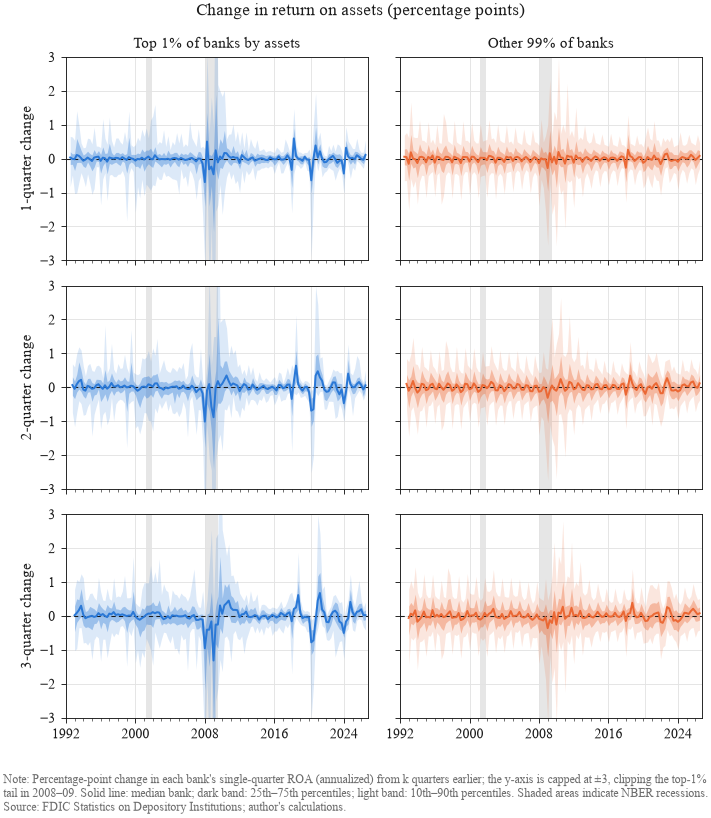

In [21]:
fig, axes = lag_figure("roa")
add_note(fig, "Note: Percentage-point change in each bank's single-quarter ROA (annualized) from k quarters earlier; "
              "the y-axis is capped at \u00b13, clipping the top-1% tail in 2008\u201309. "
              + BAND_NOTE + SOURCE)
save(fig, "size_diff_roa")
plt.show()

saved output/figures/size_diff_nim.pdf, .png and _bare.pdf


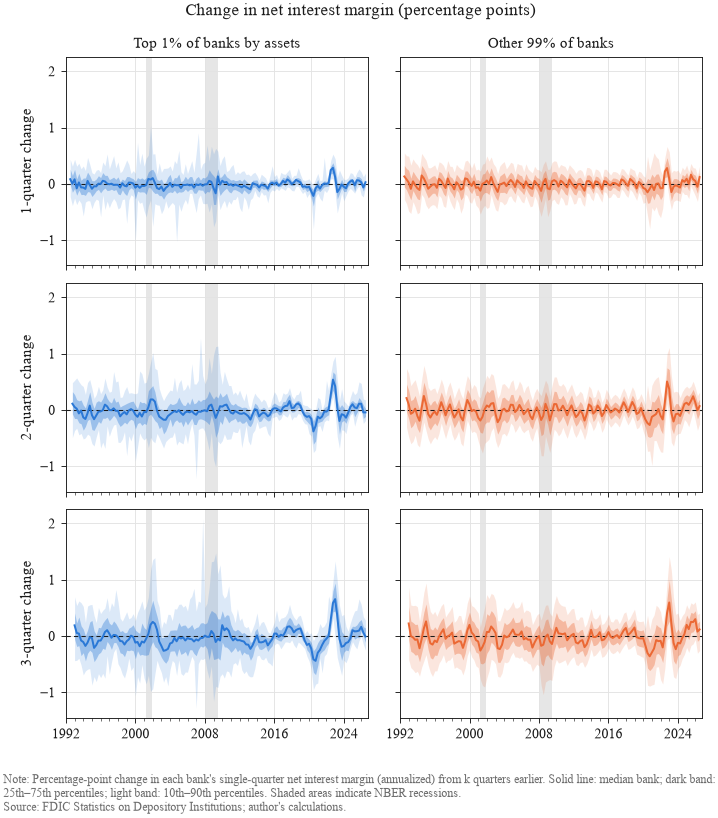

In [22]:
fig, axes = lag_figure("nim")
add_note(fig, "Note: Percentage-point change in each bank's single-quarter net interest margin (annualized) "
              "from k quarters earlier. " + BAND_NOTE + SOURCE)
save(fig, "size_diff_nim")
plt.show()

### Symmetry and dispersion summary

Quantile-based statistics, computed each quarter from the same percentiles plotted above and then averaged over expansion and recession quarters:

- **Bowley (quartile) skewness** $= (q_{75} + q_{25} - 2q_{50}) / (q_{75} - q_{25})$: symmetry of the middle half, bounded in $[-1, 1]$, and $0$ for a symmetric distribution.
- **Kelley (decile) skewness** $= (q_{90} + q_{10} - 2q_{50}) / (q_{90} - q_{10})$: the same idea for the 10th–90th range, so it picks up tail asymmetry.
- **IQR** $= q_{75} - q_{25}$: spread of the middle half, in the variable's units.

A recession quarter is any quarter that overlaps an NBER recession span. The tables are written to `output/tables/` for the LaTeX write-up.

In [23]:
TABLES = ROOT / "output" / "tables"
TABLES.mkdir(parents=True, exist_ok=True)

q_start = dist.index.get_level_values("date").unique().to_period("Q").start_time
q_end = dist.index.get_level_values("date").unique()
in_recession = pd.Series(
    [any(s <= r_end and e >= r_start for r_start, r_end in RECESSIONS) for s, e in zip(q_start, q_end)],
    index=q_end,
)
print(f"{in_recession.sum()} recession quarters, {(~in_recession).sum()} expansion quarters")

rows = []
for group in GROUPS:
    for col in diff_cols:
        d = dist.loc[group, col].dropna()
        iqr = d[0.75] - d[0.25]
        stats = pd.DataFrame({
            "median": d[0.50],
            "iqr": iqr,
            "bowley": (d[0.75] + d[0.25] - 2 * d[0.50]) / iqr,
            "kelley": (d[0.90] + d[0.10] - 2 * d[0.50]) / (d[0.90] - d[0.10]),
        })
        regime = np.where(in_recession.reindex(stats.index), "recession", "expansion")
        for reg, s in stats.groupby(regime):
            var, k = col.rsplit("_d", 1)
            rows.append({"group": group, "variable": var, "lag": int(k), "regime": reg,
                         "quarters": len(s), **s.mean().to_dict()})

summary = pd.DataFrame(rows).set_index(["variable", "lag", "group", "regime"]).sort_index()
summary.round(3)

11 recession quarters, 127 expansion quarters


quarters  median     iqr  bowley  kelley
variable     lag group regime                                             
assets       1   rest  expansion       126   1.115   4.374   0.079   0.157
                       recession        11   2.195   5.245   0.089   0.204
                 top   expansion       126   1.441   4.711   0.130   0.242
                       recession        11   1.744   6.357   0.092   0.179
             2   rest  expansion       125   2.419   6.580   0.095   0.201
                       recession        11   3.951   7.825   0.112   0.259
                 top   expansion       125   3.226   8.075   0.175   0.315
                       recession        11   4.048  10.036   0.152   0.302
             3   rest  expansion       124   3.740   8.508   0.111   0.242
                       recession        11   5.641  10.004   0.142   0.319
                 top   expansion       124   5.261  11.871   0.189   0.368
                       recession        11   6.513  14.511   0.225   0.355
equity_ratio 1   rest  expansion       126   0.029   0.561  -0.043  -0.090
                       recession        11  -0.107   0.683  -0.095  -0.193
                 top   expansion       126   0.019   0.495  -0.002   0.013
                       recession        11  -0.067   0.870   0.022   0.044
             2   rest  expansion       125   0.036   0.809  -0.035  -0.076
                       recession        11  -0.141   0.955  -0.096  -0.222
                 top   expansion       125   0.029   0.752   0.005   0.044
                       recession        11  -0.098   1.186  -0.024  -0.075
             3   rest  expansion       124   0.042   0.985  -0.029  -0.069
                       recession        11  -0.139   1.148  -0.107  -0.250
                 top   expansion       124   0.047   0.978   0.004   0.050
                       recession        11  -0.167   1.412  -0.088  -0.121
nim          1   rest  expansion       126   0.000   0.267  -0.001  -0.004
                       recession        11  -0.029   0.349  -0.030  -0.063
                 top   expansion       126  -0.013   0.198   0.020   0.017
                       recession        11  -0.011   0.331  -0.038   0.023
             2   rest  expansion       125  -0.002   0.356   0.001  -0.000
                       recession        11  -0.077   0.488  -0.055  -0.101
                 top   expansion       125  -0.022   0.294  -0.014   0.025
                       recession        11  -0.018   0.477  -0.043   0.043
             3   rest  expansion       124  -0.007   0.419   0.004   0.009
                       recession        11  -0.114   0.582  -0.075  -0.133
                 top   expansion       124  -0.031   0.367   0.010   0.022
                       recession        11  -0.019   0.639  -0.035   0.032
roa          1   rest  expansion       126   0.005   0.465  -0.000   0.003
                       recession        11  -0.024   0.614  -0.026  -0.044
                 top   expansion       126   0.005   0.359   0.016  -0.014
                       recession        11  -0.088   1.078  -0.049  -0.020
             2   rest  expansion       125   0.011   0.518   0.002   0.009
                       recession        11  -0.056   0.700  -0.044  -0.076
                 top   expansion       125   0.016   0.438  -0.008  -0.023
                       recession        11  -0.220   1.203  -0.036  -0.128
             3   rest  expansion       124   0.016   0.560   0.008   0.016
                       recession        11  -0.112   0.714  -0.097  -0.151
                 top   expansion       124   0.031   0.487  -0.023  -0.033
                       recession        11  -0.368   1.171  -0.065  -0.130

In [24]:
VAR_LABELS = {"assets": "Total assets (\\%)", "equity_ratio": "Equity to assets (pp)",
              "roa": "Return on assets (pp)", "nim": "Net interest margin (pp)"}


def latex_table(stat, fmt):
    wide = summary[stat].unstack(["group", "regime"])
    lines = []
    for var in DIFF_VARS:
        lines.append(rf"\multicolumn{{5}}{{l}}{{\textit{{{VAR_LABELS[var]}}}}} \\")
        for k in LAGS:
            r = wide.loc[(var, k)]
            cells = [fmt.format(round(r[(g, reg)], 2) or 0.0).replace("-", "$-$")  # no "-0.00"
                     for g in ("top", "rest") for reg in ("expansion", "recession")]
            lines.append(rf"\quad $k={k}$ & " + " & ".join(cells) + r" \\")
        lines.append(r"\addlinespace")
    body = "\n".join(lines[:-1])
    return (r"\begin{tabular}{@{}lcccc@{}}" "\n" r"\toprule" "\n"
            rf" & \multicolumn{{2}}{{c}}{{Top {TOP_PCT}\% of banks}} & "
            rf"\multicolumn{{2}}{{c}}{{Other {100 - TOP_PCT}\% of banks}} \\" "\n"
            r"\cmidrule(lr){2-3} \cmidrule(l){4-5}" "\n"
            r" & Expansion & Recession & Expansion & Recession \\" "\n" r"\midrule" "\n"
            + body + "\n" r"\bottomrule" "\n" r"\end{tabular}" "\n")


for stat, fmt in [("bowley", "{:.2f}"), ("kelley", "{:.2f}"), ("iqr", "{:.2f}"), ("median", "{:.2f}")]:
    (TABLES / f"size_diff_{stat}.tex").write_text(latex_table(stat, fmt), encoding="utf-8")
print("wrote", ", ".join(f"output/tables/size_diff_{s}.tex" for s in ["bowley", "kelley", "iqr", "median"]))

wrote output/tables/size_diff_bowley.tex, output/tables/size_diff_kelley.tex, output/tables/size_diff_iqr.tex, output/tables/size_diff_median.tex
